In [1]:
import numpy as np  
import matplotlib.pyplot as plt   
import os


In [ ]:
os.chdir('C:\\Users\\weido\\ch2_log_reg')
os.getcwd()

In [2]:
# load data    
#dataset_pd = np.loadtxt("marks.txt", delimiter=",")  
#np.savetxt("marks1.txt",dataset_pd, delimiter=",", fmt="%5.0f")
dataset = np.loadtxt("grades_train.txt", delimiter=",")  
X = dataset[:, :-1]    
y = dataset[:, -1]
X_1 = X[np.where(dataset[:,-1]==1)]
X_0 = X[np.where(dataset[:,-1]==0)]
  

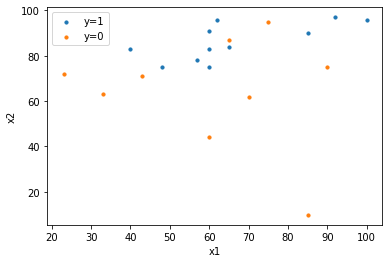

In [9]:
plt.scatter(X_1[:,0], X_1[:,1], s=10, label='y=1')
plt.scatter(X_0[:,0], X_0[:,1], s=10, label='y=0')  
plt.xlabel('x1')  
plt.ylabel('x2')  
plt.legend()
plt.show()

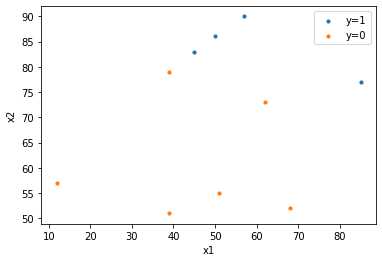

In [10]:
# load data    
#dataset_pd = np.loadtxt("marks.txt", delimiter=",")  
#np.savetxt("marks1.txt",dataset_pd, delimiter=",", fmt="%5.0f")
dataset_test = np.loadtxt("grades_test.txt", delimiter=",")  
X_test = dataset_test[:, :-1]    
y_test = dataset_test[:, -1]
X_1_test = X_test[np.where(dataset_test[:,-1]==1)]
X_0_test = X_test[np.where(dataset_test[:,-1]==0)]

plt.scatter(X_1_test[:,0], X_1_test[:,1], s=10, label='y=1')  
plt.scatter(X_0_test[:,0], X_0_test[:,1], s=10, label='y=0')  
plt.xlabel('x1')  
plt.ylabel('x2')  
plt.legend()
plt.show()  

In [21]:
X_0.shape

(9, 2)

In [11]:
def sigmoid(x):  
   return 1 / (1 + np.exp(-x))  

def h(theta, x):  
    # Returns the probability after passing through sigmoid 
    return sigmoid(np.matmul(x,theta))  


In [12]:
def cost_function(theta, x, y): 
    # Computes the cost function for all the training samples  
    m = x.shape[0]  
    t1=np.dot(np.transpose((np.log(h(theta,x)))),y)  
    t2=np.dot(np.transpose((np.log(1-h(theta,x)))),1-y)  
    total_cost = -(1 / m) * (t1+t2)   
    return total_cost  


In [13]:
def gradient(theta, x, y):  
    # Computes the gradient of the cost function at the point theta  
    m = x.shape[0]  
    return (1 / m) * np.matmul(x.T, h(theta,x) - y)  


In [14]:
def gradient_descent(alpha, x, y, numIterations):  
    # x.shape=(m,n+1), the first column is one
    # y.shape=(m,1)
    # theta.shape (n+1,1)
    cost=[]   
      
    theta = np.zeros((x.shape[1], 1))  
      
    for iter in range(0, numIterations):  
        theta=theta-alpha*gradient(theta,x,y)  
        J=cost_function(theta,x,y)  
        cost.append(J)  
    return theta,cost;  


theta by gradient_decent: [[-6.55274552]
 [-0.00865777]
 [ 0.09343879]]


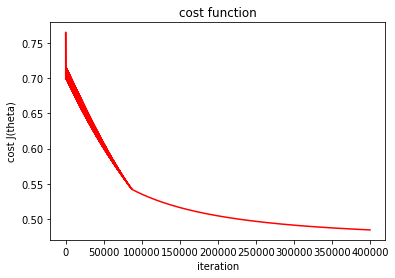

In [24]:
# prepare data in np.ndarray format  
X_add_ones=np.c_[np.ones((X.shape[0],1)), X]   # add 1 to X:(m,n+1)  
y_2d=np.expand_dims(y, axis=1) # y: (m,), y_2d: (m,1)

# learn the model by gradient descent  
theta, cost=gradient_descent(0.0009,X_add_ones,y_2d,400000)  
# X_add_ones: (m, n+1)
# y_2d: (m,1)
print("theta by gradient_decent:", theta)   
cost1=np.ndarray.flatten(np.array(cost))  
plt.plot(cost1, color='red')  
plt.xlabel('iteration')  
plt.ylabel('cost J(theta)')  
plt.title('cost function')  
plt.show()  


In [27]:
theta.shape

(3, 1)

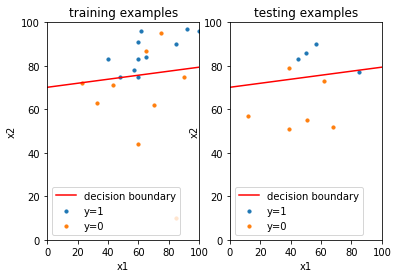

In [35]:
# plot decision boundaries   
x_values = [0, 100]
y_values_my = - (theta[0][0] + np.dot(theta[1][0], x_values)) / theta[2][0]  

plt.subplot(1, 2, 1)
plt.plot(x_values, y_values_my, label='decision boundary', color='red')  
plt.scatter(X_1[:,0], X_1[:,1], s=10, label='y=1')  
plt.scatter(X_0[:,0], X_0[:,1], s=10, label='y=0') 
plt.xlim([0,100])
plt.ylim([0,100])
plt.xlabel('x1')  
plt.ylabel('x2')  
plt.legend(loc='lower left')  
plt.title('training examples')

plt.subplot(1, 2, 2)
plt.plot(x_values, y_values_my, label='decision boundary', color='red')  
#plt.plot(x_values, y_values_sklearn, label='sklearn decision boundary', color='green', linestyle='dotted')  
plt.scatter(X_1_test[:,0], X_1_test[:,1], s=10, label='y=1')  
plt.scatter(X_0_test[:,0], X_0_test[:,1], s=10, label='y=0') 
plt.xlim([0,100])
plt.ylim([0,100])
plt.xlabel('x1')  
plt.ylabel('x2')  
plt.legend(loc='lower left')    
plt.title('testing examples')  
plt.show()  



In [104]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
X_add_ones=np.c_[np.ones((X.shape[0],1)), X]   # add 1 to X:(m,n+1) 
prob=np.ndarray.flatten(h(theta,X_add_ones)) 
# predicted probability for each example

temp=np.ndarray.flatten(np.asarray([prob>0.5])) 
# predicted true/false for each example

y_pred=temp.astype(int)  
# predicted label 1 or 0 for each example
 
results = confusion_matrix(y, y_pred) 
print ('Confusion Matrix :')
print(results)
print ('Accuracy Score :',accuracy_score(y, y_pred)) 
print ('Report : ')
print (classification_report(y, y_pred)) 



Confusion Matrix :
[[ 7  2]
 [ 1 10]]
Accuracy Score : 0.85
Report : 
              precision    recall  f1-score   support

         0.0       0.88      0.78      0.82         9
         1.0       0.83      0.91      0.87        11

    accuracy                           0.85        20
   macro avg       0.85      0.84      0.85        20
weighted avg       0.85      0.85      0.85        20



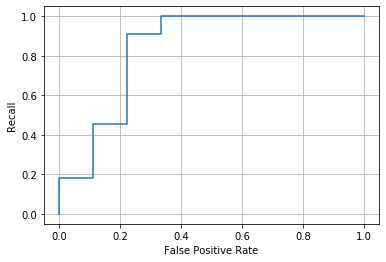

In [107]:
fpr, recall, thresholds = roc_curve(y,prob)
#create ROC curve
plt.plot(fpr,tpr)
plt.ylabel('Recall')
plt.xlabel('False Positive Rate')
plt.grid()
plt.show()
auc = roc_auc_score(y, prob)

In [93]:
prob

array([0.43327642, 0.62040456, 0.74079444, 0.69276422, 0.20905554,
       0.13526837, 0.09256952, 0.79628781, 0.47654987, 0.10668865])

In [94]:
y_test

array([0., 0., 1., 1., 0., 0., 0., 1., 1., 0.])

In [106]:
auc

0.8383838383838385

In [17]:
from sklearn.linear_model import LogisticRegression  
from sklearn.metrics import accuracy_score   
model = LogisticRegression(solver='lbfgs')  
model.fit(X_add_ones[:,1:], np.ndarray.flatten(y_2d))  # data array without ONE column  

par_sklearn = model.coef_  
intercept= model.intercept_  


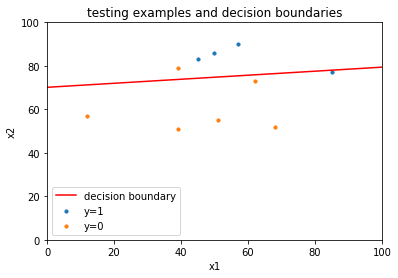

In [18]:
# plot decision boundaries   
#x_values = [np.min(X[:, 0] - 5), np.max(X[:, 1] + 5)]     
x_values=[0,100]
y_values_my = - (theta[0][0] + np.dot(theta[1][0], x_values)) / theta[2][0]  
y_values_sklearn = - (intercept + np.dot(par_sklearn[0][0], x_values)) / par_sklearn[0][1]  
plt.plot(x_values, y_values_my, label='decision boundary', color='red')  
#plt.plot(x_values, y_values_sklearn, label='sklearn decision boundary', color='green', linestyle='dotted')  
plt.scatter(X_1_test[:,0], X_1_test[:,1], s=10, label='y=1')  
plt.scatter(X_0_test[:,0], X_0_test[:,1], s=10, label='y=0') 
plt.xlim([0,100])
plt.ylim([0,100])
plt.xlabel('x1')  
plt.ylabel('x2')  
plt.legend(loc='lower left')    
plt.title('testing examples and decision boundaries')  
plt.show()  

In [38]:
# calculate classification accuracy for gradient descent
h_pred=np.matmul(X_add_ones,theta)  
y_pred=[h_pred>0]  
correct=[y_pred==y_2d]   
accuracy_gradient = accuracy_score(y_2d.flatten(),np.array(y_pred).flatten()) 

#calculate classification accuracy for sklearn
predicted_classes = model.predict(X_add_ones[:,1:])  
accuracy_sklearn = accuracy_score(y_2d.flatten(),predicted_classes)  

In [39]:
accuracy_gradient

0.85

In [ ]:
accuracy_sklearn

In [41]:
Xaxis = np.arange(0.001, 1., 0.01)

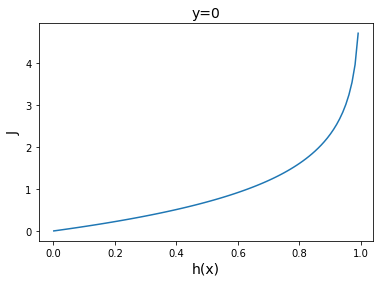

In [42]:
plt.plot(Xaxis,-np.log(1-Xaxis))
plt.xlabel('h(x)',fontsize=14,)
plt.ylabel('J',fontsize=14,)
plt.title('y=0',fontsize=14,)

plt.show()

In [ ]:
# Python script for confusion matrix creation. 
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
actual = [1, 1, 0, 1, 0, 0, 1, 0, 0, 0] 
predicted = [1, 0, 0, 1, 0, 0, 1, 1, 1, 0] 
results = confusion_matrix(actual, predicted) 
print ('Confusion Matrix :')
print(results) 
print ('Accuracy Score :',accuracy_score(actual, predicted)) 
print ('Report : ')
print (classification_report(actual, predicted)) 
